In [1]:
import torch
from torch import nn

from clean_code.flexible_bitter_llm import FlexibleBitterLLM, Gemma2RotaryEmbedding, IndependentWrapperGater
from clean_code.bitter_llm import RandomGater
torch.serialization.add_safe_globals([nn.modules.sparse.Embedding, FlexibleBitterLLM])

from transformers import AutoTokenizer

import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML
import pickle

import numpy as np

import os

In [2]:
# Refactoring the plotting functions to be more modular:
# Helper function: visualize the hard to predict tokens.
def plot_character_intensities(txt, intensities, intensity_to_value_fn=lambda x: x, colorbar_label="intensity"):
    # Get the token logits (cross-entropy loss for each token)    
    # Normalize the logits to a probability-like scale (higher logits = higher probability of being gated)
    # We use softmax-like normalization to get values between 0 and 1
    # Ensure gate_probs and input_text have the same length
    # The first token is not predicted, so we set its intensity to 0
    #     
    # Create HTML with colored text based on probabilities
    colored_text = ""
    colorbar = ""
    
    # Create a colorbar showing the gradient
    for i in range(11):  # 0.0 to 1.0 in steps of 0.1
        intensity = i / 10
        r = min(1.0, intensity)
        b = max(0.0, 1.0 - intensity)
        color = f"rgb({int(r*255)}, 0, {int(b*255)})"
        white = f"rgb(255, 255, 255)"
        colorbar += f'<span style="color:{white}; background-color:{color}; margin-right:2px; padding:0 5px;">{intensity_to_value_fn(intensity):.2f}</span>'
    
    # Add a legend for the colorbar
    colorbar_html = f'''
    <div style="margin-bottom:10px;">
        <div style="font-family:monospace; font-size:12px; margin-bottom:3px;">{colorbar_label}</div>
        <div style="font-family:monospace; font-size:14px;">{colorbar}</div>
    </div>
    '''
    
    # Process the text with colors
    for char, intensity in zip(txt, intensities):
        # Convert probability to color (blue->red)
        r = min(1.0, intensity)  # Red increases with probability
        b = max(0.0, 1.0 - intensity)  # Blue decreases with probability
        color = f"rgb({int(r*255)}, 0, {int(b*255)})"
        # Add the colored character to the output
        colored_text += f'<span style="color:{white}; background-color:{color};">{char}</span>'
    
    # Display the colorbar and colored text
    display(HTML(f'''
    <div>
        {colorbar_html}
        <div style="font-family:monospace; font-size:14px;">{colored_text}</div>
    </div>
    '''))

In [3]:
train_losses_4 = pd.read_csv('experiment_31/train_losses_4.csv')
train_losses_5 = pd.read_csv('experiment_31/train_losses_5.csv')

train_losses_6 = pd.read_csv('experiment_31/train_losses_6.csv') # 6 uses a different config for the gater.

train_losses_4.head()

,ar_loss,late_ar_loss,early_ar_loss,gating_loss,true_downsample_rate,rate_consistency_loss,total_loss,selected_action_ce,bytes_elapsed
0,1.003156,0.952769,1.204702,0.000120,0.587320,0.011378,1.014654,0.637324,32768
1,1.057238,1.011576,1.239888,0.000090,0.465513,0.004645,1.061973,0.637789,65536
2,1.068203,1.020071,1.260732,0.000006,0.383171,0.001773,1.069983,0.646398,98304
3,1.029793,0.982420,1.219285,0.000182,0.329265,0.000628,1.030603,0.653822,131072
4,1.101738,1.058936,1.272949,0.000065,0.292248,0.000178,1.101982,0.662874,163840


In [4]:
def plot_train_losses(losses, column_name):
    # Add a smoothed version of the loss curve
    window_size = 20
    smoothed_ar_loss = losses[column_name].rolling(window=window_size).mean()

    plt.figure(figsize=(10, 6))
    plt.plot(losses[column_name], alpha=0.3, color='blue', label=f'{column_name} (raw)')
    plt.plot(smoothed_ar_loss, linewidth=2, color='blue', label=f'{column_name} (smoothed, window={window_size})')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss (nats/token)')
    plt.title(f'{column_name} During Training (Raw and Smoothed)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

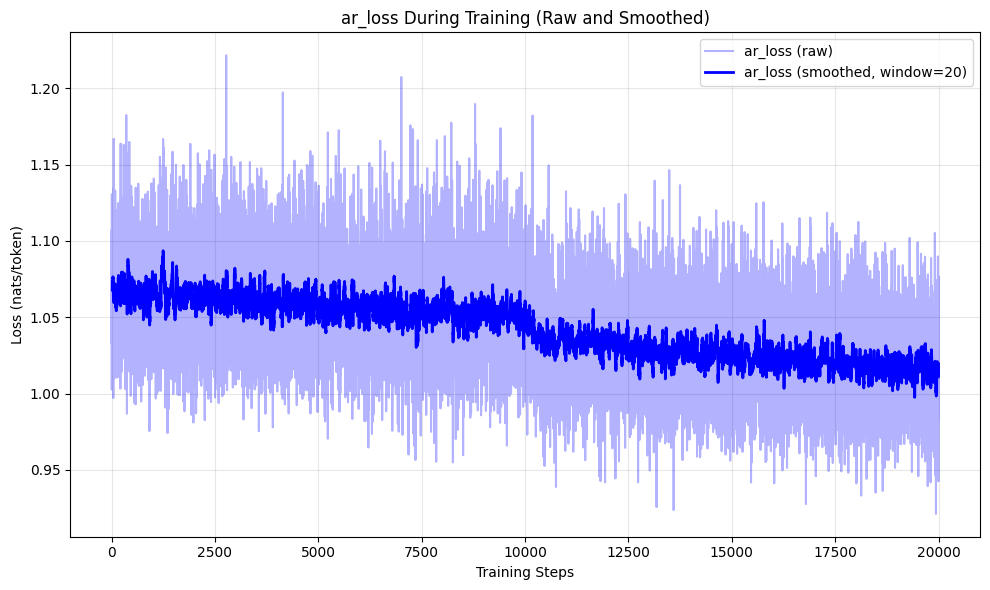

In [5]:
plot_train_losses(train_losses_4, "ar_loss")

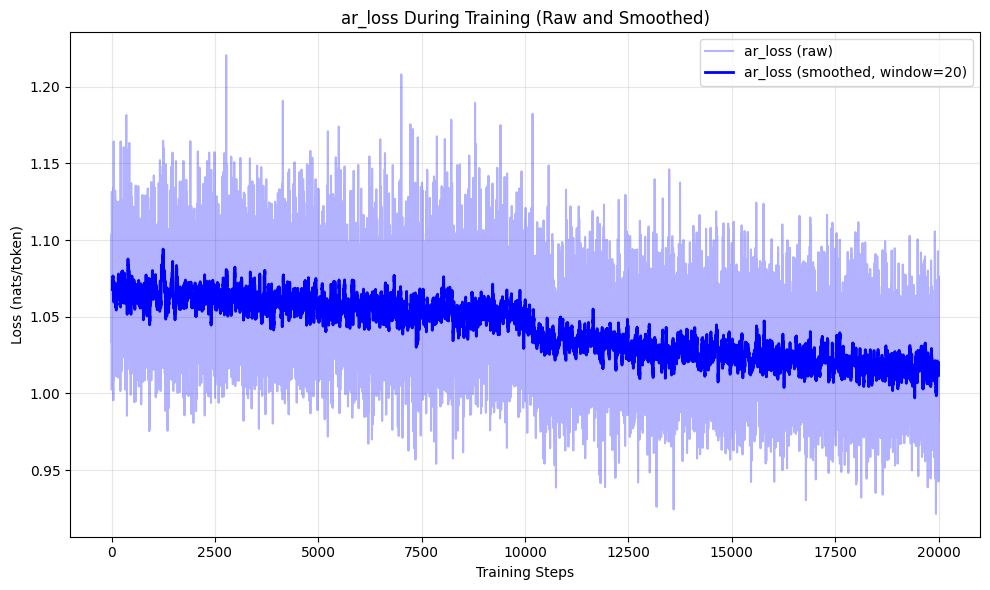

In [6]:
plot_train_losses(train_losses_5, "ar_loss")

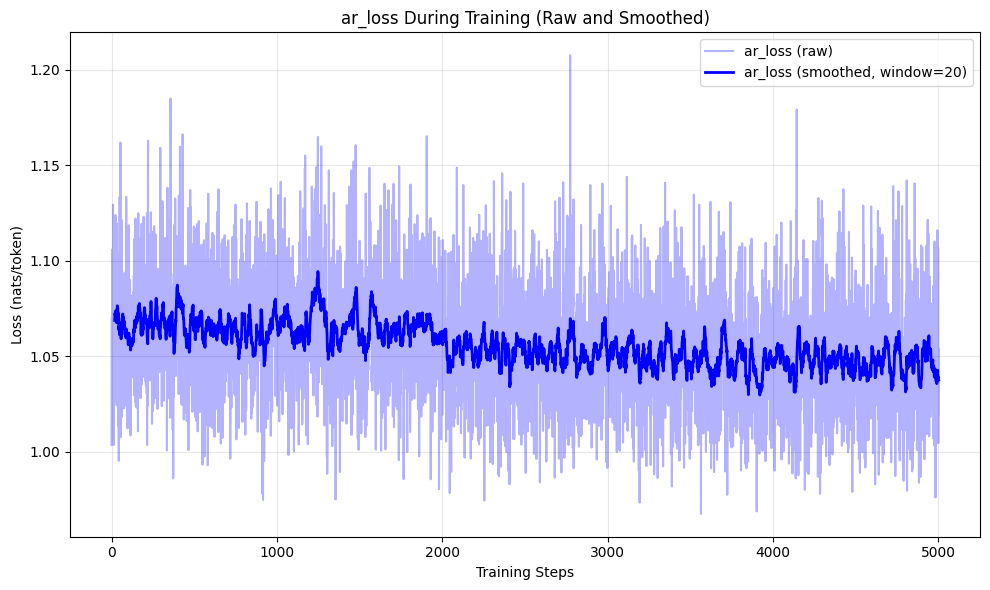

In [7]:
plot_train_losses(train_losses_6, "ar_loss")

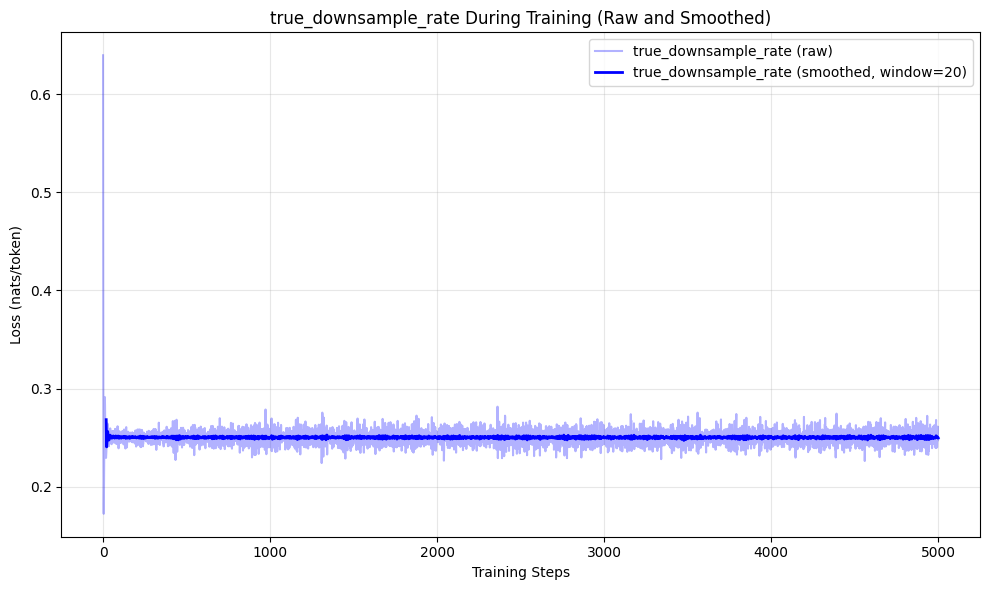

In [8]:
plot_train_losses(train_losses_6, "true_downsample_rate")

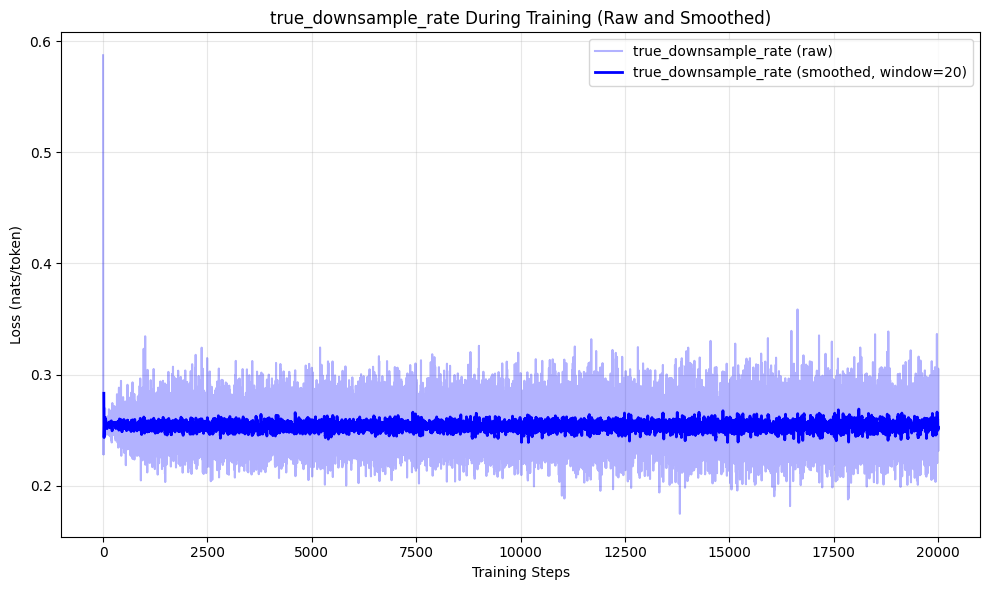

In [9]:
plot_train_losses(train_losses_4, "true_downsample_rate")


Observations:
- Almost all of them converge to an average downsample rate of 0.25, but with quite high inter-example variance
- You can actually pick out the improvement from the tokenization scheme (maybe this could actually be investigated further and decoupled from "anything consistent will do", set the ar loss to zero).
---

In [10]:
with open("./test_openwebtext_samples.pkl", 'rb') as f:
    my_samples = pickle.load(f)
    my_samples = my_samples["text"]

test_string = my_samples[0]
len(test_string), test_string

(4491,
 'CHICAGO -- Size is a nice characteristic to have in hockey, but the Chicago Blackhawks have proven it\'s not everything.\n\nThe Blackhawks have emphasized speed and skill over size, and they\'ve been successful, winning two of the past five Stanley Cup championships (2010 and 2013).\n\nChicago is preparing for its fifth Western Conference Final in the past seven seasons and is considered by some as the favorite to defeat the bigger Anaheim Ducks; Game 1 is Sunday at Honda Center (3 p.m. ET; NBC, CBC, TVA Sports). That probably wouldn\'t have happened a decade ago, when giant men on skates clogged the ice surface, but the NHL and game have changed.\n\nBeing small isn\'t a detriment anymore for guys with great hands and the ability to skate fast.\n\n"I would say if it was like the early 2000s or late \'90s, it seemed like it was a bigger man\'s game and it would be tough for guys [my] size to end up even making the NHL," said 5-foot-11, 177-pound right wing Patrick Kane, who lea

In [11]:
byte5_tokenizer = AutoTokenizer.from_pretrained("google/byt5-large")

In [24]:
my_model = torch.load("experiment_31/model_5.pt", weights_only=False)

In [25]:
test_batch = byte5_tokenizer(test_string, return_tensors="pt")["input_ids"]
test_batch = test_batch[:, :1024]
test_batch = test_batch.to("cuda")

In [26]:
with torch.no_grad():
    out = my_model(test_batch)

In [27]:
def plot_gate_probs(model_out):
    gate_probs = model_out["down_gate_probs"]
    gate_probs = gate_probs.detach().cpu().numpy()
    plot_character_intensities(test_string, gate_probs[0], colorbar_label="gate probability")

plot_gate_probs(out)

Observation: it really likes to gate on proper nouns. It also sometimes gates on whitespaces (!).

Reasons for the obsession with proper nouns:
- _maybe_ the obsession with proper nouns is due to the gating supression being super weak or even amplifying for some reason.
- _maybe_ the obsession with proper nouns is due to the greediness of the model ($\gamma = 0.9$)
- _maybe_ the obsession with proper nouns is due to this really being the best thing _for this architecture_ (maybe the aggregation is just quite weak and so an entire spelling can't be passed into the induction heads)
---

Digging into the learned filter:

In [29]:
from clean_code.conditional_sequential import SequentiallyDependentLinearGater

In [30]:
class VerboseFilterGater(SequentiallyDependentLinearGater):
    def precompute_filter_weights(self, x: torch.Tensor) -> torch.Tensor:
        weights = super().precompute_filter_weights(x)
        print(weights.shape)
        return weights


In [31]:
my_model.down_layer_gate.__class__ = VerboseFilterGater

In [32]:
my_model(test_batch)

torch.Size([1, 1024, 5])


{'logits': tensor([[[-29.4399, -13.7144, -23.6082,  ..., -23.7947, -24.5859, -24.1877],
          [-30.5063, -18.1923, -28.7584,  ..., -27.4666, -27.9770, -28.2965],
          [-37.5234, -14.0891, -25.9550,  ..., -25.2743, -23.9780, -26.4739],
          ...,
          [-42.2111, -20.4739, -31.4100,  ..., -32.5911, -31.0295, -29.1865],
          [-35.3690, -20.9806, -28.5834,  ..., -25.3816, -27.1663, -30.2008],
          [-41.8260, -15.4223, -33.7529,  ..., -33.7843, -32.5551, -34.4643]]],
        device='cuda:0', grad_fn=<LogSoftmaxBackward0>),
 'early_logits': tensor([[[-33.1221, -14.3464, -29.4970,  ..., -28.6576, -29.7862, -29.0368],
          [-30.2432, -15.8798, -26.4431,  ..., -25.8005, -26.1401, -26.7361],
          [-33.0378, -11.8707, -22.0663,  ..., -21.5427, -20.8650, -22.4073],
          ...,
          [-25.6132, -14.4576, -23.1793,  ..., -22.4212, -23.4474, -24.1300],
          [-27.5277, -14.4228, -27.9446,  ..., -26.1943, -27.6191, -28.5350],
          [-34.1351, -14.53